# WiniCari 02 Prétraitement : Reconstruction des Trajets GPS

**Objectif :** transformer les pings GPS bruts (`Historique_pos`) en **trajets reconstruits avec une heure d'arrivée réelle dérivée par arrêt** — la fondation partagée pour la prédiction de Retard (labels), la Détection d'Anomalies et le Repli GPS.

**Pourquoi la dériver :** `service` / `session_ouverte` n'enregistrent que quand un conducteur *ouvre* une course. L'arrivée au terminus, le demi-tour et le **trajet retour ne sont jamais enregistrés** (un conducteur ouvre généralement un service pour toute la journée, `voyages` est vide). Les trajets ne peuvent donc être récupérés qu'à partir de la **trace GPS**.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.db import get_db
from src.data import foundation as fdn

db_winicari = get_db("winicari")
db_gps = get_db("Historique_pos")

CFG = fdn.Config()         
CFG

Config(min_anchors=4, min_pings=300, first_usable_day='d20220601', dedup_round=6, signal_gap_s=600, proj_window=3, proj_gap_reset_s=900, smooth_window=15, reversal_frac=0.15, reversal_floor_m=2000.0, min_span_frac=0.06, min_span_floor_m=1500.0, min_trip_min=8.0, layover_gap_s=2400, park_frac=0.05, full_frac=0.1, arrival_thresh_m=350.0)

## Géométrie des lignes — conserver les ancres géocodées, ignorer les placeholders

`array_lat/lng_opendata` mappe une coordonnée par arrêt, mais beaucoup d'arrêts sont stockés comme `0.0`
(non géocodés). On conserve les **ancres** géocodées dans l'ordre de l'itinéraire et on saute les autres — une couverture partielle n'est pas une raison d'abandonner une ligne. `code` n'est **pas unique entre compagnies**, donc on indexe tout par `(code, societe)`.

In [2]:
# One query builds {(code, societe) -> anchor stops with cumulative route distance}
USABLE = fdn.build_usable_lines(db_winicari, CFG)

n_zero = sum(len(fdn.real_anchor_stops(ligne)) == 0
             for ligne in db_winicari["ligne"].find({}, {"array_lat_opendata": 1,
                                                          "array_lng_opendata": 1}))
print(f"usable (code, societe) lines: {len(USABLE)} | lines with 0 geocoded stops: {n_zero}")
USABLE[("209", "S.R.T.K")].head()

usable (code, societe) lines: 135 | lines with 0 geocoded stops: 249


,seq,route_seq,name,lat,lon,s_m
0,0,0,KASSERINE,35.178056,8.847499,0.000000
1,1,1,BOUZGUEM,35.209142,8.894370,5485.235148
2,2,2,EL GARRAA,35.228854,8.960128,11848.232621
3,3,3,CHRAYA,35.255313,9.022020,18192.423815
4,4,4,SBEITLA,35.231061,9.130617,28416.628099


## Audit de la géométrie des arrêts — quelle est la complétude du réseau ?

Pour chaque ligne, on compte : arrêts totaux déclarés, géocodés (vrai lat/lon), manquants (stockés comme `0.0`).
On classe chaque ligne dans l'un des cinq types :

| type | signification |
|---|---|
| `full` | chaque arrêt géocodé |
| `partial` | certains arrêts géocodés, certains manquants |
| `terminal_only` | seulement 1–2 arrêts géocodés (généralement uniquement origine + terminus) |
| `no_geometry` | arrêts déclarés mais aucun géocodé |
| `no_stops` | pas du tout de tableau d'arrêts dans la config |

Les lignes classées `terminal_only` sont celles que vous soupçonniez : route_km est juste une distance à vol d'oiseau entre les deux extrémités — **pas** la distance réelle sur route.

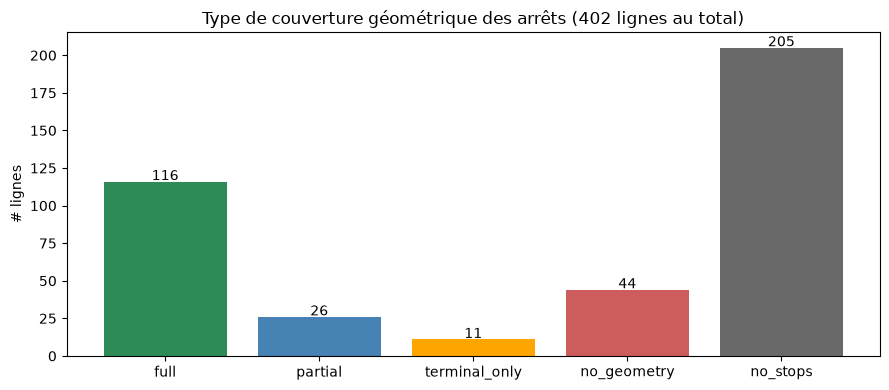

coverage_type
full             116
partial           26
terminal_only     11
no_geometry       44
no_stops         205

Total lignes : 402  |  avec géométrie : 153  |  sans géométrie (0 géocodé) : 249


In [3]:
from pathlib import Path
import numpy as np

LD = Path(fdn.__file__).resolve().parents[2] / "data" / "processed" / "line_distances.parquet"
ld = pd.read_parquet(LD)

ct = ld["coverage_type"].value_counts().reindex(
    ["full", "partial", "terminal_only", "no_geometry", "no_stops"])

plt.figure(figsize=(9, 4))
colors = ["seagreen", "steelblue", "orange", "indianred", "dimgrey"]
bars = plt.bar(ct.index, ct.values, color=colors)
for b, v in zip(bars, ct.values):
    plt.text(b.get_x() + b.get_width()/2, v + 1, str(v), ha="center", fontsize=10)
plt.ylabel("# lignes"); plt.title("Type de couverture géométrique des arrêts (402 lignes au total)")
plt.tight_layout(); plt.show()

print(ct.to_string())
print(f"\nTotal lignes : {len(ld)}  |  avec géométrie : {(ld['geocoded_stops']>0).sum()}  "
      f"|  sans géométrie (0 géocodé) : {(ld['geocoded_stops']==0).sum()}")

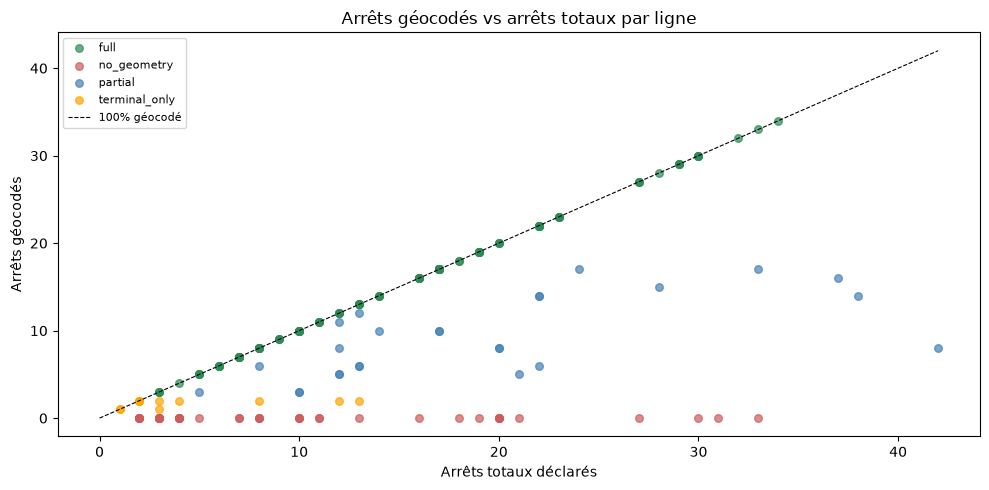

In [4]:
has_stops = ld[ld["total_stops"] > 0].copy()
cmap = {"full":"seagreen","partial":"steelblue","terminal_only":"orange",
        "no_geometry":"indianred","no_stops":"dimgrey"}

plt.figure(figsize=(10, 5))
for ct_type, grp in has_stops.groupby("coverage_type"):
    plt.scatter(grp["total_stops"], grp["geocoded_stops"],
                label=ct_type, color=cmap.get(ct_type,"grey"), alpha=0.7, s=30)
plt.plot([0, has_stops["total_stops"].max()],
         [0, has_stops["total_stops"].max()],
         "k--", lw=0.8, label="100% géocodé")
plt.xlabel("Arrêts totaux déclarés"); plt.ylabel("Arrêts géocodés")
plt.title("Arrêts géocodés vs arrêts totaux par ligne")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

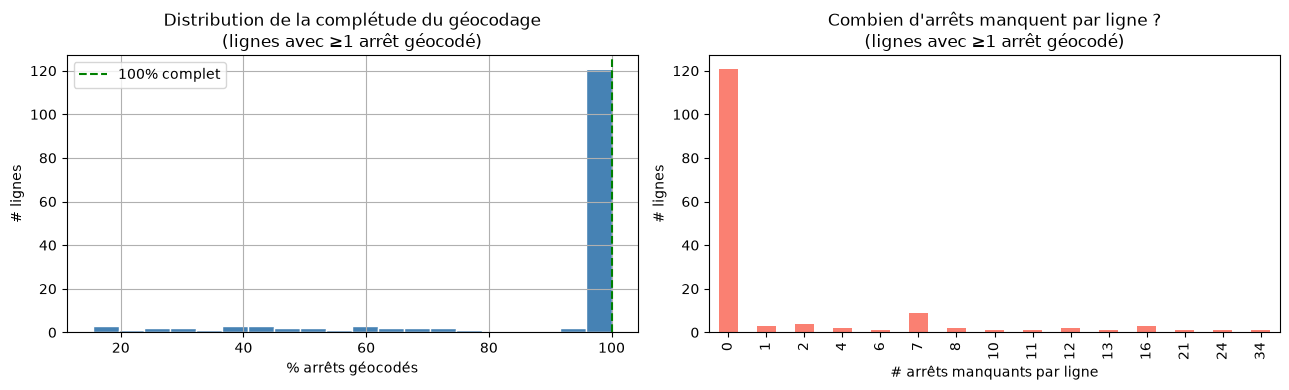

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

has_geo = ld[ld["geocoded_stops"] > 0]
has_geo["pct_geocoded"].hist(bins=20, ax=ax[0], color="steelblue", edgecolor="white")
ax[0].axvline(100, color="green", ls="--", label="100% complet")
ax[0].set_xlabel("% arrêts géocodés"); ax[0].set_ylabel("# lignes")
ax[0].set_title("Distribution de la complétude du géocodage\n(lignes avec ≥1 arrêt géocodé)")
ax[0].legend()

has_geo["missing_stops"].value_counts().sort_index().head(20).plot(kind="bar", ax=ax[1], color="salmon")
ax[1].set_xlabel("# arrêts manquants par ligne"); ax[1].set_ylabel("# lignes")
ax[1].set_title("Combien d'arrêts manquent par ligne ?\n(lignes avec ≥1 arrêt géocodé)")
plt.tight_layout(); plt.show()

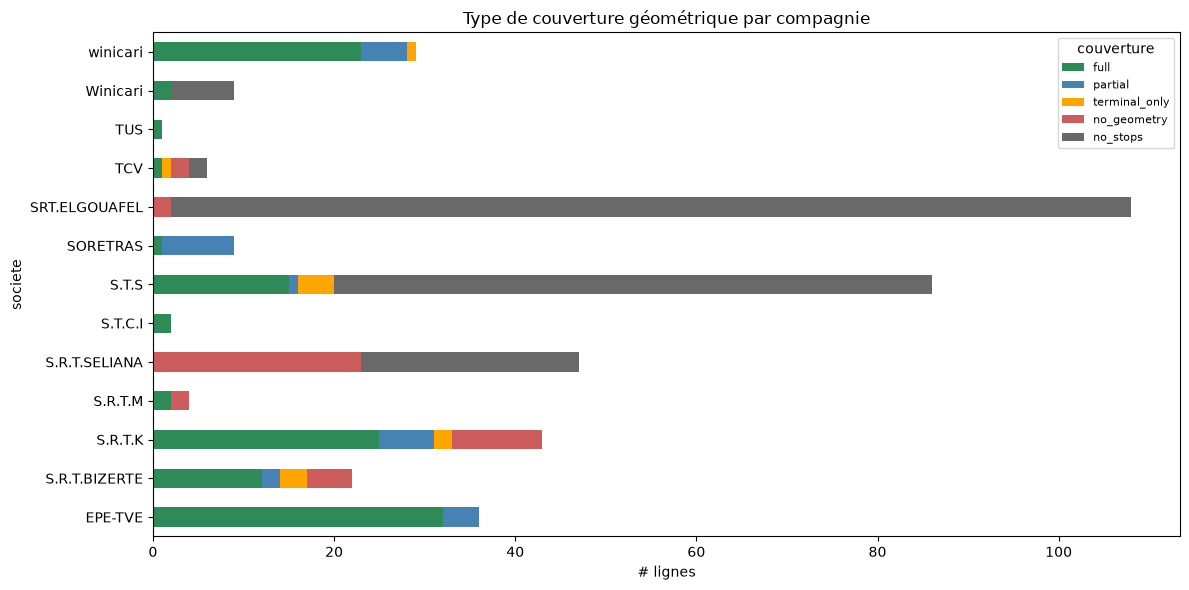


Lignes terminal_only (11) — route_km est une distance à vol d'oiseau origine→terminus uniquement :
    line        societe  total_stops  geocoded_stops  missing_stops  route_km
16   116  S.R.T.BIZERTE            2               2              0    41.394
17   103  S.R.T.BIZERTE            2               2              0    54.452
30   102  S.R.T.BIZERTE            2               2              0    55.852
98   220          S.T.S           12               2             10    25.675
99   221          S.T.S            4               2              2   244.970
102  224          S.T.S           13               2             11     2.102
159  213          S.T.S            8               2              6    10.585
161  999        S.R.T.K            1               1              0     0.000
190  999       winicari            1               1              0     0.000
217  105        S.R.T.K            3               2              1     5.485
229    1            TCV            3      

In [6]:
order = ["full", "partial", "terminal_only", "no_geometry", "no_stops"]
colors = {"full":"seagreen","partial":"steelblue","terminal_only":"orange",
          "no_geometry":"indianred","no_stops":"dimgrey"}

pivot = (ld.groupby(["societe","coverage_type"]).size()
           .unstack(fill_value=0)
           .reindex(columns=order, fill_value=0))

pivot.plot(kind="barh", stacked=True, figsize=(12, 6),
           color=[colors[c] for c in order])
plt.xlabel("# lignes"); plt.title("Type de couverture géométrique par compagnie")
plt.legend(title="couverture", bbox_to_anchor=(1,1), fontsize=8)
plt.tight_layout(); plt.show()

show_cols = [c for c in ["line","societe","total_stops","geocoded_stops","missing_stops","route_km"] if c in ld.columns]
term = ld[ld["coverage_type"]=="terminal_only"][show_cols]
print(f"\nLignes terminal_only ({len(term)}) — route_km est une distance à vol d'oiseau origine→terminus uniquement :")
print(term.to_string())

### Ce que cela signifie pour le pipeline

- **`full` (116 lignes) :** tous les arrêts géocodés → route_km est précis, le taux d'accrochage devrait être élevé.
- **`partial` (26 lignes) :** lacunes au milieu → route_km sous-estime (sauts manquants) ; le taux d'accrochage sera plus faible pour les arrêts manquants. Le pipeline saute les placeholders `0.0` et utilise les ancres restantes.
- **`terminal_only` (11 lignes) :** seulement origine + terminus géocodés → route_km est une **distance à vol d'oiseau**, inférieure à la vraie distance routière. Le pipeline traite ces lignes comme des lignes à 2 ancres ; `min_anchors=4` signifie qu'elles ne sont **pas utilisables** pour la reconstruction de trajets.
- **`no_geometry` (44 lignes) :** arrêts déclarés mais coordonnées toutes `0.0` → pipeline les rejette entièrement.
- **`no_stops` (205 lignes) :** pas du tout de tableau d'arrêts → la plupart sont SRT.ELGOUAFEL et S.R.T.SELIANA. Le pipeline ne peut pas les utiliser. Le seul correctif est que ces compagnies géocodent leurs arrêts.

## 1. Charger et nettoyer une journée de bus

`load_pings` normalise la dérive du schéma (`localisation.x=lat`, `.y=lon` ; vitesse = `speed` de niveau supérieur sinon `bus.vitesse`). `clean_pings` supprime les doublons stationnaires consécutifs (~10 %) et signale les écarts de signal. On fixe un exemple interurbain propre pour la reproductibilité.

In [7]:
# Show all stops for a given line with their coordinates, cumulative distance, and ordered geometry
LINE, SOCIETE = "209", "S.R.T.K"
stops = USABLE[(LINE, SOCIETE)]

# Add distance between consecutive stops for reference
stops_display = stops.copy()
stops_display["distance_to_next_km"] = 0.0
for i in range(len(stops_display) - 1):
    stops_display.loc[i, "distance_to_next_km"] = (
        (stops_display.loc[i+1, "s_m"] - stops_display.loc[i, "s_m"]) / 1000
    )

# Format and display
display_cols = ["seq", "name", "lat", "lon", "s_m", "distance_to_next_km"]
stops_summary = stops_display[display_cols].copy()
stops_summary["s_m"] = (stops_summary["s_m"] / 1000).round(2)  # convert to km
stops_summary["distance_to_next_km"] = stops_summary["distance_to_next_km"].round(2)
stops_summary.columns = ["Stop #", "Stop Name", "Latitude", "Longitude", "Cumulative Distance (km)", "Distance to Next Stop (km)"]

print(f"\n{LINE} {SOCIETE} — All {len(stops)} Stops in Route Order")
print("="*120)
display(stops_summary)

# Summary statistics
total_distance = stops["s_m"].max() / 1000
print(f"\nTotal route distance: {total_distance:.1f} km | Average stop spacing: {total_distance / len(stops):.2f} km")


209 S.R.T.K — All 22 Stops in Route Order


,Stop #,Stop Name,Latitude,Longitude,Cumulative Distance (km),Distance to Next Stop (km)
0,0,KASSERINE,35.178056,8.847499,0.00,5.49
1,1,BOUZGUEM,35.209142,8.894370,5.49,6.36
2,2,EL GARRAA,35.228854,8.960128,11.85,6.34
3,3,CHRAYA,35.255313,9.022020,18.19,10.22
4,4,SBEITLA,35.231061,9.130617,28.42,7.72
5,5,OUED ELMIOU,35.207744,9.210719,36.14,7.09
6,6,ESSABALA,35.177449,9.279409,43.23,8.21
7,7,EL BLAKAT,35.147836,9.362125,51.44,7.88
8,8,M'AMMER,35.121844,9.442698,59.32,8.88
9,9,BLAK BOUZID,35.099726,9.536530,68.20,11.39



Total route distance: 192.0 km | Average stop spacing: 8.73 km


In [8]:
LINE, SOCIETE, BUS, DAY = "209", "S.R.T.K", 6030, "d20260615"
stops = USABLE[(LINE, SOCIETE)]

raw = fdn.load_pings(db_gps, DAY, LINE, BUS)
g = fdn.clean_pings(raw, CFG)
print(f"line {LINE} {SOCIETE} bus {BUS} {DAY[1:]} | stops={len(stops)}")
print(f"raw pings {len(raw)} -> cleaned {len(g)} (removed {len(raw)-len(g)} stationary, "
      f"{100*(len(raw)-len(g))//len(raw)}%) | median interval {g['gap_s'].median():.0f}s "
      f"| signal gaps {int(g['signal_gap'].sum())} | largest {g['gap_s'].max():.0f}s")
g.head()

line 209 S.R.T.K bus 6030 20260615 | stops=22
raw pings 4023 -> cleaned 3582 (removed 441 stationary, 10%) | median interval 5s | signal gaps 4 | largest 3607s


,t,lat,lon,speed,gap_s,signal_gap
0,2026-06-15 09:51:43.431,35.177807,8.847803,0.00000,NaN,False
1,2026-06-15 09:53:08.483,35.177807,8.847807,0.00000,85.052,False
2,2026-06-15 09:53:18.483,35.177807,8.847805,0.14816,10.000,False
3,2026-06-15 09:53:58.500,35.177807,8.847807,0.00000,40.017,False
4,2026-06-15 09:54:58.518,35.177807,8.847805,0.00000,60.018,False


## 2. Accrocher chaque ping à une distance de route

`project_to_route` effectue une **projection séquentielle (fenêtrée)** sur la polyligne d'ancrage, donnant une distance-le-long-de-la-route `s` lisse (et une déviation hors-route `off_m`). Le fenêtrage maintient `s` physiquement lisse malgré des ancres éparses — la clé d'une segmentation propre.

longueur de l'itinéraire (polyligne d'ancrage) : 192 km | distance hors-itinéraire moyenne : 336 m


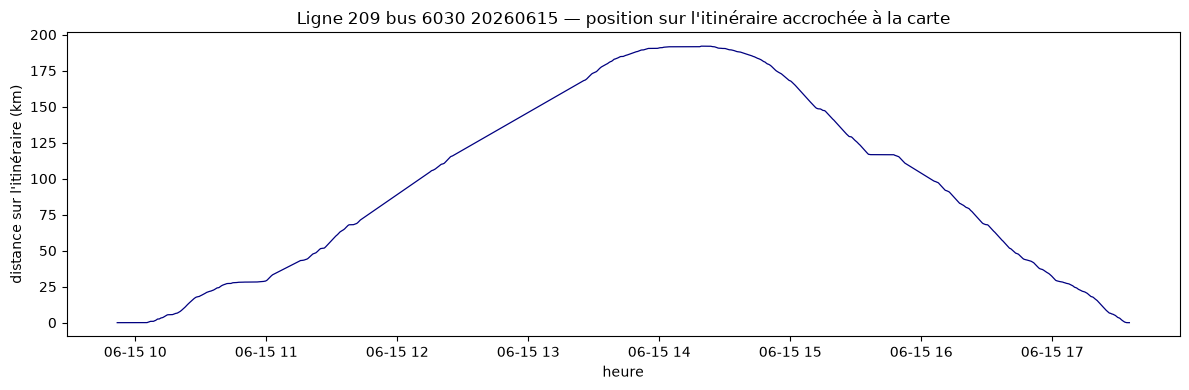

In [9]:
g, route_len = fdn.project_to_route(g, stops, CFG)
print(f"longueur de l'itinéraire (polyligne d'ancrage) : {route_len/1000:.0f} km | "
      f"distance hors-itinéraire moyenne : {g['off_m'].mean():.0f} m")

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.9, color="navy")
plt.ylabel("distance sur l'itinéraire (km)"); plt.xlabel("heure")
plt.title(f"Ligne {LINE} bus {BUS} {DAY[1:]} — position sur l'itinéraire accrochée à la carte")
plt.tight_layout(); plt.show()

## 3. Segmenter les trajets — complets **et** partiels

`segment_trips` détecte les **renversements de direction** (demi-tours) à l'aide d'une hystérésis indépendante de l'échelle (fraction de la longueur de l'itinéraire), donc fonctionne aussi bien pour une ligne interurbaine de 200 km que pour une boucle urbaine de 6 km. Elle fractionne une course dans la même direction **uniquement** lors d'un écart d'attente *garé* (grand écart temporel où le bus n'a presque pas bougé) — donc un écart de signal en milieu d'itinéraire ne fragmente **pas** une course, et un bus qui rebrousse chemin tôt est conservé comme trajet **partiel**.

détecté 2 trajets (2 complets, 0 partiels)
      dir  full  start    end     km
0   ALLER  True  09:51  14:19  192.0
1  RETOUR  True  14:19  17:35  192.0


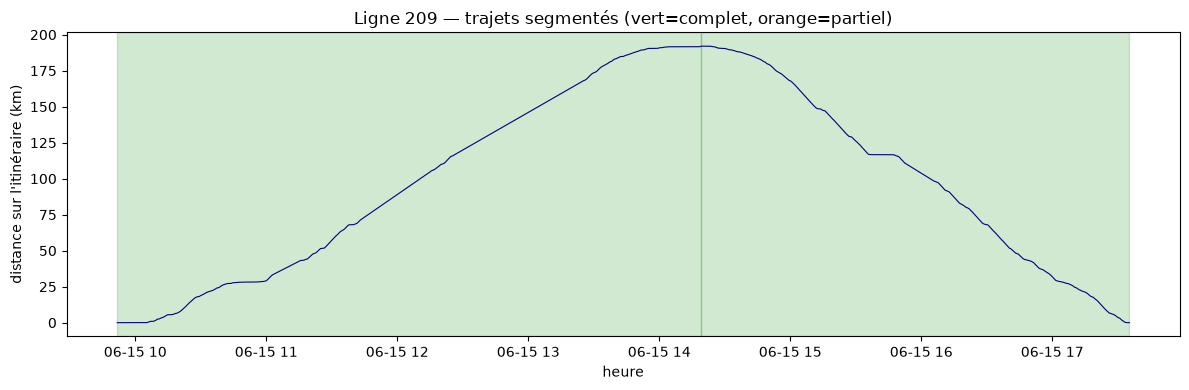

In [10]:
trips = fdn.segment_trips(g, route_len, CFG)
view = trips.assign(start=trips["start"].dt.strftime("%H:%M"),
                    end=trips["end"].dt.strftime("%H:%M"),
                    km=((trips["s_hi"] - trips["s_lo"]) / 1000).round(1))[
    ["dir", "full", "start", "end", "km"]]
print(f"détecté {len(trips)} trajets ({trips['full'].sum()} complets, {(~trips['full']).sum()} partiels)")
print(view.to_string())

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.8, color="navy")
for _, tr in trips.iterrows():
    plt.axvspan(tr["start"], tr["end"], alpha=0.18,
                color="green" if tr["full"] else "orange")
plt.ylabel("distance sur l'itinéraire (km)"); plt.xlabel("heure")
plt.title(f"Ligne {LINE} — trajets segmentés (vert=complet, orange=partiel)")
plt.tight_layout(); plt.show()

## 4. Dériver l'heure d'arrivée réelle par arrêt

### Le problème en termes simples
Imaginez un bus avec un appareil GPS qui enregistre sa position toutes les 5 secondes. Mais la **base de données NE stocke PAS quand le bus est arrivé à chaque arrêt** — seulement les positions GPS brutes.

Votre mission : **déterminer à quelle heure le bus est réellement arrivé à chaque arrêt** en analysant la trace GPS.

### Exemple pas à pas

Supposons qu'un bus s'arrête à KASSERINE, BOUZGUEM et SFAX (dans cet ordre).

**Étape 1 : Ce qu'on sait**
```
ARRÊTS sur l'itinéraire :
├─ Arrêt 0 : KASSERINE    aux coordonnées (35,178 ; 8,847)
├─ Arrêt 1 : BOUZGUEM    aux coordonnées (35,209 ; 8,894)
└─ Arrêt 2 : SFAX        aux coordonnées (34,722 ; 10,757)

PINGS GPS du bus (toutes les 5 secondes) :
├─ 09:54:30  à (35,177 ; 8,847)  ← GPS est JUSTE à KASSERINE, mais est-ce l'arrivée ?
├─ 09:55:18  à (35,178 ; 8,847)  ← GPS est JUSTE à KASSERINE de nouveau
├─ 09:55:25  à (35,177 ; 8,848)  ← encore très proche de KASSERINE
├─ 10:05:32  à (35,178 ; 8,848)  ← toujours à KASSERINE (garé, en attente)
├─ 10:14:53  à (35,209 ; 8,894)  ← GPS saute à BOUZGUEM (bus a commencé à bouger)
├─ 10:17:23  à (35,210 ; 8,895)  ← toujours à BOUZGUEM
├─ ... (nombreux pings) ...
└─ 14:19:16  à (34,722 ; 10,757) ← arrivé à SFAX
```

**Étape 2 : Associer chaque arrêt à son premier ping** (dans les 350 mètres)
```
Pour KASSERINE (35,178 ; 8,847) :
  ✓ 09:54:30 est à 100 m    ← PREMIÈRE correspondance, utiliser ceci
  ✓ 09:55:18 est à 50 m     ← ignorer, ping plus tardif
  ✓ 09:55:25 est à 80 m     ← ignorer, ping plus tardif
  ✓ 10:05:32 est à 90 m     ← ignorer, ping plus tardif

Pour BOUZGUEM (35,209 ; 8,894) :
  ✓ 10:14:53 est à 30 m     ← PREMIÈRE correspondance, utiliser ceci

Pour SFAX (34,722 ; 10,757) :
  ✓ 14:19:16 est à 50 m     ← PREMIÈRE correspondance, utiliser ceci
```

**Étape 3 : Trouver quand le bus a QUITTÉ chaque arrêt**
```
Quand le bus a-t-il quitté KASSERINE ?
  ← Chercher le premier ping APRÈS l'arrivée qui n'est PAS à KASSERINE
  ← Le ping à 10:14:53 s'est déplacé aux coordonnées de BOUZGUEM
  → Le bus a quitté KASSERINE et est arrivé à BOUZGUEM à 10:14:53

Donc :
  Arrivée à KASSERINE :        09:54:30
  Départ de KASSERINE :        10:14:53  (qui est aussi l'arrivée à BOUZGUEM)
  Durée d'immobilisation à KASSERINE : 10:14:53 - 09:54:30 = 20 minutes 23 secondes
```

### Le tableau résultant

| Arrêt | Nom de l'arrêt | Arrivée | Départ | Immobilisation (min) | Accroché |
|-------|----------------|---------|--------|---------------------|----------|
| 0 | KASSERINE | 09:54:30 | 10:14:53 | 20,4 | ✓ |
| 1 | BOUZGUEM | 10:14:53 | 10:17:23 | 2,5 | ✓ |
| 2 | SFAX | 14:19:16 | 14:19:16 | 0,0 | ✓ |

---

### Cas particuliers du monde réel

**Que se passe-t-il si un arrêt n'est PAS trouvé ?**
```
Arrêt : EL FAIDH aux coordonnées (35,057 ; 9,650)
Pings GPS les plus proches de EL FAIDH : tous à plus de 350 m

Résultat :
├─ Arrivée : NaN (nul/manquant)
├─ Départ : NaN
├─ Immobilisation : NaN
└─ Accroché : ✗ (Faux)

Pourquoi ?
→ Les coordonnées de l'arrêt peuvent être incorrectes
→ Le GPS avait un écart et a manqué cet arrêt
→ Le bus a réellement sauté cet arrêt
```

**Que se passe-t-il si le bus stationne longtemps à un arrêt ?**
```
Pings GPS à KASSERINE :
├─ 09:54:30  (lat=35,178, lon=8,847)  ← ARRIVÉE
├─ 09:55:00  (lat=35,178, lon=8,847)  ← toujours là, garé
├─ 09:56:00  (lat=35,178, lon=8,847)  ← toujours là, garé
├─ 10:05:00  (lat=35,178, lon=8,847)  ← toujours là, garé
├─ 10:14:53  (lat=35,209, lon=8,894)  ← DÉPART (déplacé à l'arrêt suivant)

Résultat :
├─ Arrivée : 09:54:30
├─ Départ : 10:14:53
└─ Immobilisation : 20 minutes 23 secondes ✓ (temps d'embarquement des passagers)
```

---

### Résumé
`derive_arrivals` est un **algorithme d'accrochage** qui :
1. ✓ Trouve le **ping GPS le plus proche** pour chaque arrêt (dans les 350 m)
2. ✓ Enregistre le **moment de ce ping** comme heure d'arrivée
3. ✓ Calcule **combien de temps le bus est resté** à chaque arrêt
4. ✗ Marque les arrêts **introuvables** comme non accrochés

Cela crée les **heures d'arrivée/départ** qui manquaient dans la base de données brute.

In [11]:
# Show the state of the data right before arrival derivation
tr = trips.iloc[0]
seg_pings = g[(g["t"] >= tr["start"]) & (g["t"] <= tr["end"])].copy()

print(f"Trip {tr['dir']}: {tr['start']} to {tr['end']}")
print(f"Pings in this trip: {len(seg_pings)}")
print(f"\nBefore derive_arrivals — raw pings with map-matched route position:")
print(seg_pings[["t", "s", "off_m", "speed"]].head(20).to_string())

# Show the covered range of the route
print(f"\nTrip covers route from {seg_pings['s'].min()/1000:.1f} km to {seg_pings['s'].max()/1000:.1f} km")
print(f"Number of stops in this range: {((stops['s_m'] >= seg_pings['s'].min()) & (stops['s_m'] <= seg_pings['s'].max())).sum()}")

# Show what stops the bus is supposed to visit during this trip
trip_stops = stops[(stops["s_m"] >= seg_pings["s"].min()) & (stops["s_m"] <= seg_pings["s"].max())][["seq", "name", "s_m"]]
print(f"\nStops the bus should visit in order:")
print(trip_stops.assign(s_m_km=trip_stops["s_m"]/1000).to_string())

Trip ALLER: 2026-06-15 09:51:43.431000 to 2026-06-15 14:19:16.612000
Pings in this trip: 1594

Before derive_arrivals — raw pings with map-matched route position:
                         t         s      off_m    speed
0  2026-06-15 09:51:43.431  4.262433  39.065166  0.00000
1  2026-06-15 09:53:08.483  4.263020  39.256371  0.00000
2  2026-06-15 09:53:18.483  4.263020  39.160769  0.14816
3  2026-06-15 09:53:58.500  4.263020  39.256371  0.00000
4  2026-06-15 09:54:58.518  4.321303  39.160769  0.00000
5  2026-06-15 09:55:18.519  4.379586  39.016620  0.00000
6  2026-06-15 09:55:48.536  4.497326  39.112222  0.00000
7  2026-06-15 09:56:18.552  4.615066  39.303427  0.27780
8  2026-06-15 09:56:23.552  5.321505  39.877043  0.37040
9  2026-06-15 09:56:33.552  5.555811  39.828497  0.00000
10 2026-06-15 09:56:38.553  5.790117  39.779950  0.18520
11 2026-06-15 09:56:43.553  6.142162  39.827006  0.18520
12 2026-06-15 09:56:48.553  6.378816  39.921118  0.25928
13 2026-06-15 09:57:03.554  6.378816  4

In [12]:
tr = trips.iloc[0]
arr = fdn.derive_arrivals(g, tr, stops, CFG)
print(f"Trip 0 ({tr['dir']}, full={tr['full']}): matched {arr['matched'].sum()}/{len(arr)} "
      f"covered stops ({arr['matched'].mean():.0%})")
arr.assign(arrival=arr["arrival"].dt.strftime("%H:%M:%S"))

Trip 0 (ALLER, full=True): matched 13/22 covered stops (59%)


,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,0,0,KASSERINE,09:55:18,2026-06-15 10:05:32.434,613.9,39,True
1,1,1,BOUZGUEM,10:14:53,2026-06-15 10:17:23.494,150.0,6,True
2,2,2,EL GARRAA,10:23:27,2026-06-15 10:23:37.524,10.0,136,True
3,3,3,CHRAYA,10:29:17,2026-06-15 10:29:32.632,15.0,20,True
4,4,4,SBEITLA,10:57:40,2026-06-15 10:58:55.358,75.1,113,True
5,5,5,OUED ELMIOU,NaN,NaT,NaN,2927,False
6,6,6,ESSABALA,11:16:22,2026-06-15 11:17:27.498,65.0,38,True
7,7,7,EL BLAKAT,11:24:52,2026-06-15 11:26:27.676,95.0,35,True
8,8,8,M'AMMER,11:31:17,2026-06-15 11:31:27.735,10.0,12,True
9,9,9,BLAK BOUZID,11:40:09,2026-06-15 11:40:44.413,35.0,1,True


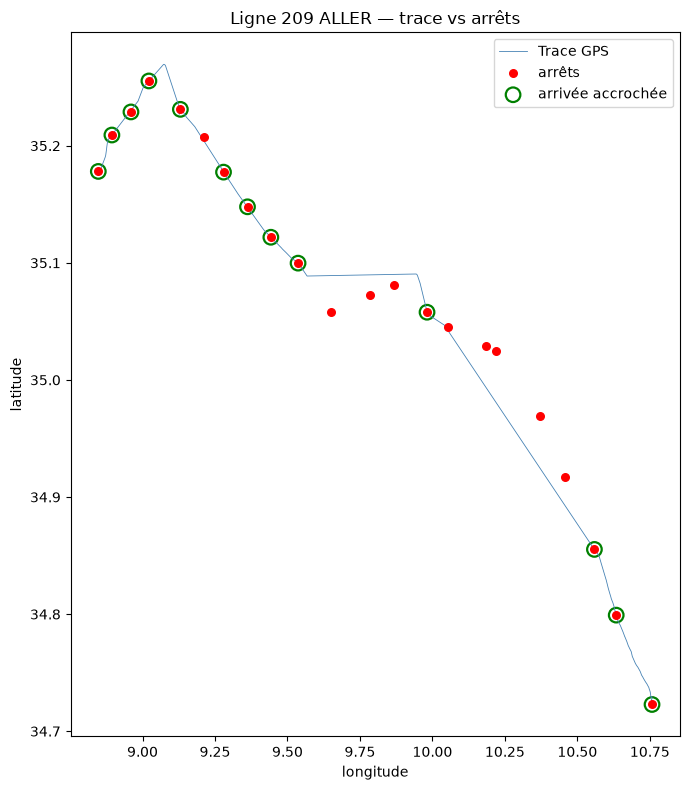

In [13]:
seg = g[(g["t"] >= tr["start"]) & (g["t"] <= tr["end"])]
matched = arr[arr["matched"]]
plt.figure(figsize=(7, 8))
plt.plot(seg["lon"], seg["lat"], linewidth=0.6, color="steelblue", label="Trace GPS")
plt.scatter(stops["lon"], stops["lat"], c="red", s=30, zorder=3, label="arrêts")
plt.scatter([stops["lon"].iloc[s] for s in matched["seq"]],
            [stops["lat"].iloc[s] for s in matched["seq"]],
            facecolors="none", edgecolors="green", s=110, linewidths=1.6, label="arrivée accrochée")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title(f"Ligne {LINE} {tr['dir']} — trace vs arrêts"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Pipeline complet pour une journée de bus

`reconstruct_bus_day` enchaîne tout ce qui précède et renvoie une ligne par arrêt couvert.

In [14]:
demo = fdn.reconstruct_bus_day(db_gps, DAY, LINE, SOCIETE, BUS, stops, CFG)
print(f"rows={len(demo)} | trips={demo['trip_id'].nunique()} | "
      f"match rate={100*demo['matched'].mean():.0f}%")
print("columns:", list(demo.columns))
demo.head(12)

rows=44 | trips=2 | match rate=75%
columns: ['day', 'line', 'societe', 'bus', 'trip_id', 'dir', 'full', 'trip_start', 'trip_end', 'seq', 'route_seq', 'stop', 'arrival', 'departure', 'dwell_s', 'dist_m', 'matched']


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,0,0,KASSERINE,2026-06-15 09:55:18.519,2026-06-15 10:05:32.434,613.9,39,True
1,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,1,1,BOUZGUEM,2026-06-15 10:14:53.457,2026-06-15 10:17:23.494,150.0,6,True
2,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,2,2,EL GARRAA,2026-06-15 10:23:27.524,2026-06-15 10:23:37.524,10.0,136,True
3,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,3,3,CHRAYA,2026-06-15 10:29:17.632,2026-06-15 10:29:32.632,15.0,20,True
4,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,4,4,SBEITLA,2026-06-15 10:57:40.230,2026-06-15 10:58:55.358,75.1,113,True
5,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,5,5,OUED ELMIOU,NaT,NaT,NaN,2927,False
6,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,6,6,ESSABALA,2026-06-15 11:16:22.479,2026-06-15 11:17:27.498,65.0,38,True
7,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,7,7,EL BLAKAT,2026-06-15 11:24:52.626,2026-06-15 11:26:27.676,95.0,35,True
8,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,8,8,M'AMMER,2026-06-15 11:31:17.734,2026-06-15 11:31:27.735,10.0,12,True
9,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,9,9,BLAK BOUZID,2026-06-15 11:40:09.397,2026-06-15 11:40:44.413,35.0,1,True


### Pourquoi construire la Fondation — La grande image

Le **jeu de données de fondation** est la **source unique de vérité partagée** pour les quatre modules IA. Il résout un problème critique :

**Le problème :**
```
Les données brutes sont dispersées et incomplètes :
├─ Base de données de billetterie (winicari) : contient les définitions d'itinéraires, coordonnées des arrêts
├─ Base de données GPS (Historique_pos) : contient les pings GPS bruts (millions par jour)
└─ Aucune ne contient d'heures d'arrivée explicites aux arrêts
```

**Ce dont on a besoin pour le ML :**
```
Pour la prédiction de RETARD :
  ✓ Heure d'arrivée réelle à chaque arrêt
  ✓ Labels de retard prévu vs réel
  ✓ Contexte bus, ligne, direction, date

Pour le REPLI GPS :
  ✓ Trace GPS propre avec positions connues
  ✓ Emplacements des arrêts sur l'itinéraire
  ✓ Écarts de signal signalés

Pour la détection d'ANOMALIES :
  ✓ Caractéristiques par trajet (durées d'immobilisation, taux d'accrochage)
  ✓ Métadonnées de trajet (complet vs partiel, compagnie)

Pour le chatbot RAG :
  ✓ Statistiques de ligne (couverture, taux d'accrochage)
  ✓ Détails des trajets anormaux
```

### La structure du jeu de données de fondation

Une ligne = une arrivée de bus à un arrêt

```
┌─ Identifiants ───────────────────────────────────┐
│ day: 20260615                                    │  quel jour
│ line: 209                                        │  quelle ligne de bus
│ societe: S.R.T.K                                │  quelle compagnie
│ bus: 6030                                        │  quel véhicule de bus
│ trip_id: 0                                       │  quel trajet ce jour-là
│ dir: ALLER                                       │  direction (ALLER/RETOUR)
│ full: True                                       │  trajet complet ou partiel ?
├─ Métadonnées du trajet ─────────────────────────┤
│ trip_start: 2026-06-15 09:51:43                 │  quand le trajet a commencé
│ trip_end: 2026-06-15 14:19:16                   │  quand le trajet s'est terminé
├─ Détails de l'arrêt ───────────────────────────┤
│ seq: 0                                           │  numéro d'arrêt le long de l'itinéraire
│ route_seq: 0                                     │  position d'arrêt d'origine
│ stop: KASSERINE                                  │  nom de l'arrêt
│ arrival: 2026-06-15 09:55:18                    │  quand le bus est arrivé (depuis accrochage GPS)
│ departure: 2026-06-15 10:05:32                  │  quand le bus est reparti (prochain ping GPS)
│ dwell_s: 613.9                                   │  secondes garées à l'arrêt
├─ Métriques de qualité GPS ─────────────────────┤
│ dist_m: 39.0                                     │  distance GPS à l'arrêt (m)
│ matched: True                                    │  arrêt trouvé avec succès ?
└────────────────────────────────────────────────┘

Exemple : le 2026-06-15, le bus 6030 sur la ligne 209 (S.R.T.K, direction ALLER)
est arrivé à KASSERINE à 09:55:18, a stationné 10 minutes 14 secondes (embarquement),
et est reparti à 10:05:32. Le GPS était à seulement 39 m de l'arrêt.
```

### Le processus de construction

```
┌────────────────────────────────────────────────────────────────┐
│                    SOURCES DE DONNÉES BRUTES                    │
│  ┌─────────────────┐      ┌──────────────────────────────────┐ │
│  │ DB winicari     │      │ DB Historique_pos (MongoDB)      │ │
│  │ ├─ ligne        │      │ d20260601, d20260602, ...        │ │
│  │ │ ├─ code       │      │ (une collection par jour)        │ │
│  │ │ ├─ arrets     │      │ Chaque doc :                     │ │
│  │ │ └─ societe    │      │  ├─ position.lat/lng             │ │
│  │ ├─ arrets       │      │  ├─ bus.code                     │ │
│  │ │ ├─ lat/lng    │      │  ├─ service.codeLigne            │ │
│  │ │ └─ noms       │      │  └─ createdAt (horodatage)       │ │
│  │ └─ tickets      │      └──────────────────────────────────┘ │
│  └─────────────────┘                                            │
└────────────────────────────────────────────────────────────────┘
                              ↓
                    [build_foundation.py]
                              ↓
    (pour chaque ligne utilisable, pour chaque jour, pour chaque bus)
    ┌─────────────────────────────────────────────┐
    │  1. Charger les pings GPS depuis MongoDB    │
    │  2. Nettoyer les pings (supprimer dups stat.)│
    │  3. Projeter les pings sur la géométrie     │
    │  4. Segmenter en trajets individuels        │
    │  5. Accrocher les arrêts aux pings (arrivée)│
    │  6. Calculer les durées d'immobilisation    │
    └─────────────────────────────────────────────┘
                              ↓
┌────────────────────────────────────────────────────────────────┐
│       SORTIE : foundation_arrivals_full.parquet                  │
│       168 481 lignes × 16 colonnes                              │
│       couvrant 3 343 combinaisons uniques (jour, ligne, bus)    │
│       avec 20 743 trajets reconstruits                          │
└────────────────────────────────────────────────────────────────┘
                              ↓
    ┌──────────────────┬──────────────────┬──────────────────┐
    │  MODULE RETARD   │  REPLI GPS       │  MODULE ANOMALIE │
    │                  │                  │                  │
    │ Utilise: arrivée,│ Utilise: trace   │ Utilise: immo.   │
    │ labels de retard │ GPS, arrêts,     │ par trajet,      │
    │ (vs horaire)     │ immobilisation   │ dist., accrochage│
    └──────────────────┴──────────────────┴──────────────────┘
```

### Statistiques clés de la Fondation construite

```
foundation_arrivals_full.parquet
├─ Lignes : 168 481 (une par arrivée à un arrêt)
├─ Jours-bus : 3 343 combinaisons uniques (jour, ligne, bus)
├─ Trajets : 20 743 voyages reconstruits
├─ Lignes : 29 lignes de bus distinctes
├─ Plage de dates : 01/01/2025 au 21/06/2026 (18 mois)
└─ Taux d'accrochage global : 76 %
    ├─ Lignes bien cartographiées (ex. 209) : 85-95 % de taux d'accrochage
    └─ Lignes mal cartographiées (urbaines) : 40-60 % de taux d'accrochage
```

### Pourquoi cette approche ?

**Au lieu de** construire des jeux de données séparés pour chaque module :
```
❌ Jeu de données Retard    ❌ Jeu GPS               ❌ Jeu Anomalie
   └─ logique séparée          └─ logique séparée        └─ logique séparée
   └─ incohérent               └─ incohérent              └─ incohérent
   └─ difficile à maintenir    └─ difficile à maintenir   └─ difficile à maintenir
```

**On construit UNE fondation, puis on la découpe :**
```
✓ Source unique de vérité
✓ Tous les modules utilisent des définitions identiques de trajets/arrêts
✓ Les changements de la fondation se propagent automatiquement
✓ Plus facile à maintenir et déboguer
✓ Haute réutilisabilité dans tout le projet
```

### Ce que cela permet en aval

Une fois la fondation existante, la construction de modèles devient **beaucoup plus simple** :

- **Module Retard** : fusionner simplement la fondation avec les horaires prévus → obtenir les labels
- **Repli GPS** : la fondation a déjà la trace GPS propre + les arrêts
- **Anomalie** : la fondation a déjà les agrégats par trajet
- **RAG** : la fondation a toutes les statistiques pour construire la base de connaissances

En résumé : **Fondation = les 80 % de travail difficile de préparation des données**. Tout le reste consiste à brancher des modèles dessus.

In [15]:
# repo root resolved from the library location -> works regardless of cwd
OUT = Path(fdn.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"
if OUT.exists():
    fa = pd.read_parquet(OUT)
    bd = fa.groupby(["day", "line", "societe", "bus"]).ngroups
    tr_n = fa.groupby(["day", "line", "societe", "bus", "trip_id"]).ngroups
    print(f"loaded {OUT.name}: rows={len(fa)} | bus-days={bd} | trips={tr_n} "
          f"| lines={fa['line'].nunique()} | overall match={100*fa['matched'].mean():.0f}%")
    print(f"day range: {fa['day'].min()} .. {fa['day'].max()} | "
          f"full trips={fa.groupby(['day','line','bus','trip_id'])['full'].first().sum()}")
else:
    fa = pd.DataFrame()
    print(f"{OUT} not found — run the CLI above to build it.")
fa.head()

loaded foundation_arrivals_full.parquet: rows=168481 | bus-days=3343 | trips=20743 | lines=29 | overall match=76%
day range: 20250101 .. 20260621 | full trips=17341


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,0,0,KASSERINE,2025-01-01 03:01:22.300,2025-01-01 03:04:52.262,210.0,92.0,True
1,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,1,1,BOUZGUEM,2025-01-01 03:14:07.268,2025-01-01 03:14:37.281,30.0,46.0,True
2,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,2,2,EL GARRAA,NaT,NaT,NaN,1238.0,False
3,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,3,3,CHRAYA,2025-01-01 03:24:01.335,2025-01-01 03:24:01.335,0.0,17.0,True
4,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,4,4,SBEITLA,2025-01-01 03:39:24.278,2025-01-01 03:39:24.278,0.0,118.0,True


bus_days  trips  stops  match_rate
societe line                                    
S.R.T.K 501          2      3      3       100.0
S.T.S   107          1     34     34       100.0
        225          3     73     73        99.0
S.R.T.K 306        144   1054   1054        95.0
S.T.S   216          7     33     33        88.0
        301         28    850    850        87.0
        306         52   2538   2538        85.0
S.R.T.K 211          5     87     87        85.0
        415          4     31     31        84.0
TCV     3          405  85412  85412        83.0
S.T.S   226         19    725    725        82.0
S.R.T.K 202        115   4749   4749        80.0
        500         10    108    108        79.0
        428          6     42     42        79.0
S.T.S   211         37   1251   1251        79.0
        101        145   6582   6582        77.0
        219         62  11732  11732        75.0
S.R.T.K 209        127   4922   4922        74.0
S.T.S   304        226  10506  10506        71.0
        541          2    122    122        70.0
S.R.T.K 217        153   7699   7699        70.0
        216         30   1413   1413        69.0
        204        116   3811   3811        68.0
        203        147   5513   5513        68.0
S.T.S   215          8     94     94        64.0
S.R.T.K 215        148   6207   6207        61.0
        205         13    129    129        61.0
        311          5     50     50        60.0
        212        280  12552  12552        55.0
        201          6    140    140        49.0
        402          1      5      5        40.0
S.T.S   515          1      9      9        11.0
S.R.T.K 424          1      1      1         0.0
S.T.S   212          1      4      4         0.0

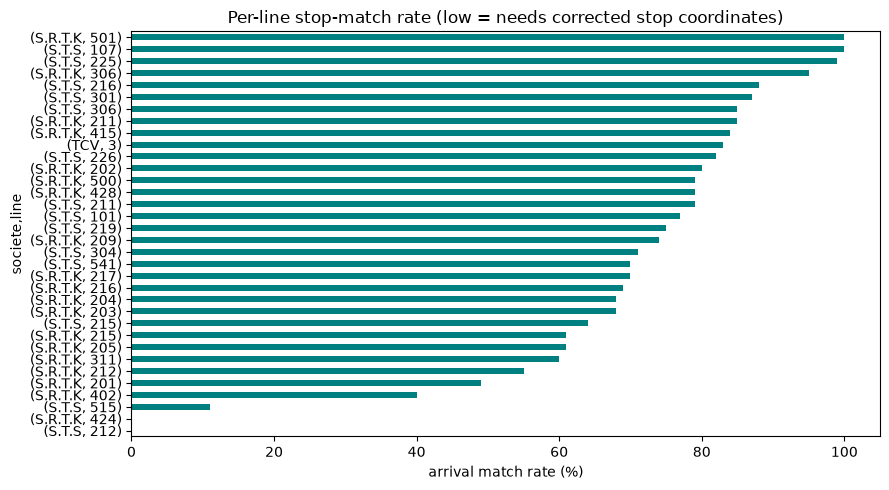

In [16]:
# Per-line match rate = headline data-quality signal (which lines have good stop coords)
if len(fa):
    per_line = (fa.groupby(["societe", "line"])
                  .agg(bus_days=("day", "nunique"), trips=("trip_id", "size"),
                       stops=("matched", "size"), match_rate=("matched", "mean"))
                  .assign(match_rate=lambda d: (100 * d["match_rate"]).round())
                  .sort_values("match_rate", ascending=False))
    display(per_line)

    ax = per_line["match_rate"].plot(kind="barh", figsize=(9, 5), color="teal")
    ax.set_xlabel("arrival match rate (%)")
    ax.set_title("Per-line stop-match rate (low = needs corrected stop coordinates)")
    ax.invert_yaxis(); plt.tight_layout(); plt.show()

### Mises en garde / notes de qualité (à redonner à l'audit)

- **La géométrie est partielle :** ~135 lignes utilisables (>= 4 ancres géocodées) ; ~249 n'en ont aucune. Les ancres éparses signifient que la polyligne n'approxime que la route — la segmentation utilise des *oscillations* de distance avec hystérésis plutôt qu'un vrai accrochage cartographique pour plus de robustesse.
- **Le taux d'accrochage par ligne est la métrique de qualité.** Les lignes interurbaines bien cartographiées obtiennent des scores élevés ; les lignes urbaines courtes et les lignes avec des coordonnées d'arrêts imprécises (ex. certaines lignes S.R.T.K) obtiennent des scores bas et devraient obtenir des coordonnées corrigées auprès de la compagnie avant d'être prêtes pour les modèles.
- **Les trajets partiels sont conservés** (bus rebrousse tôt, ou jour se termine en milieu de course) et signalés via `full=False` ; les écarts de signal en milieu d'itinéraire ne fragmentent pas une course.
- **Aucune heure programmée par arrêt n'existe encore** à soustraire — `ligne.horaires` ne contient que les heures de départ. Le labelisation du retard (réel − prévu) est le prochain notebook une fois que les horaires sont mappés par arrêt.
- Tous les paramètres réglables se trouvent dans `fdn.Config` ; le même chemin de code s'exécute dans le notebook et dans la CLI.